In [ ]:
%pip install langchain-google-genai

In [1]:
from langchain_core.messages import AIMessage
from langchain_core.tools import tool

from langgraph.prebuilt import ToolNode

In [2]:
@tool
def get_weather(location: str):
    """Call to get the current weather."""
    if location.lower() in ["sf", "san francisco"]:
        return "It's 60 degrees and foggy."
    else:
        return "It's 90 degrees and sunny."


@tool
def get_coolest_cities():
    """Get a list of coolest cities"""
    return "nyc, sf"

In [3]:
import sys
import os

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add parent directory to sys.path
sys.path.append(parent_dir)


In [4]:
from tools.product_enquiry import product_enquiry
from tools.product_enquiry import get_integrations
from tools.calendar import calender_availability


In [5]:
tools = [product_enquiry, calender_availability, get_integrations]
tool_node = ToolNode(tools)

In [6]:
def first_node():
    return "first node"

In [7]:
def second_node():
    return "second node"

In [8]:
from typing import Literal
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_anthropic import ChatAnthropic
from langgraph.graph import StateGraph, MessagesState
from langgraph.prebuilt import ToolNode

query = "What is the capital of France?"

prompt= f"respond in italian {query}"

model_with_tools =  ChatOpenAI(
    model="gpt-4o-mini", temperature=0
).bind_tools(tools, tool_choice="auto")

print(prompt.format(query))
# response = model_with_tools.invoke(prompt.format(query))


respond in italian What is the capital of France?


In [9]:
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ChatMessage

In [10]:
from prompts.prompts import EMAIL_DRAFTER_PROMPT

In [11]:
# response

In [11]:
from langgraph.graph import START, StateGraph
from state import AgentGraphState

In [12]:
def subgraph_node_1(state: AgentGraphState):
    return {"bar": "bar"}


def subgraph_node_2(state: AgentGraphState):
    # note that this node is using a state key ('bar') that is only available in the subgraph
    # and is sending update on the shared state key ('foo')
    return {"foo": state["foo"] + state["bar"]}


subgraph_builder = StateGraph(AgentGraphState)
subgraph_builder.add_node(subgraph_node_1)
subgraph_builder.add_node(subgraph_node_2)
subgraph_builder.add_edge(START, "subgraph_node_1")
subgraph_builder.add_edge("subgraph_node_1", "subgraph_node_2")
subgraph3 = subgraph_builder.compile()

In [22]:
model_with_tools.invoke("""The email is from a potential client inquiring about pricing, setup requirements, and availability for a chat, indicating a clear need for a response, We’re currently exploring solutions to streamline our sales team's workflow. Your AI Sales Research Agent caught my eye. Could you let me know about pricing and setup requirements? Also, how does it integrate with HubSpot and let me know your availability next week for a chat????""").tool_calls


[{'name': 'product_enquiry',
  'args': {'processed_email_body': 'Could you let me know about pricing and setup requirements for your AI Sales Research Agent?'},
  'id': 'call_ph5O1DGUZydTCQfdw0SOVPSQ',
  'type': 'tool_call'},
 {'name': 'integrations',
  'args': {'processed_email_body': 'How does it integrate with HubSpot?'},
  'id': 'call_ySsmEWNjtg46UbMYz02Qq7JV',
  'type': 'tool_call'},
 {'name': 'calender_availability',
  'args': {'time': 'next week'},
  'id': 'call_WORYHf59nM9jfMqEXpQgrQo2',
  'type': 'tool_call'}]

In [15]:
tool_node.invoke({"messages": [model_with_tools.invoke("We’re currently exploring solutions to streamline our sales team's workflow. Your AI Sales Research Agent caught my eye. Could you let me know about pricing and setup requirements? Also, how does it integrate with HubSpot and let me know your availability next week for a chat????")]})

{'messages': [ToolMessage(content='innovize ai helps business automate processes with ai agnets and ml models', name='product_enquiry', tool_call_id='toolu_01X9JFAv6ZfpDLbE5jzWa6cg')]}

In [14]:
from drafter_graph import create_email_drafter_graph


In [15]:
email_drafter_graph= create_email_drafter_graph(tools)


bind started sucessfully
bind completed sucessfully


In [18]:
# response= email_drafter_graph.invoke( {"messages": "Hi Pavan Kumar,\nHi Team,\nwhat is your pricing and lets setup a call?"})

In [19]:
# response

In [16]:
# example with a single tool call
for chunk in email_drafter_graph.stream(
    {"messages": [("human", "We’re currently exploring solutions to streamline our sales team's workflow. Your AI Sales Research Agent caught my eye. Could you let me know about pricing and setup requirements? Also, how does it integrate with HubSpot and let me know your availability next week for a chat??")]}, stream_mode="values"
):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

We’re currently exploring solutions to streamline our sales team's workflow. Your AI Sales Research Agent caught my eye. Could you let me know about pricing and setup requirements? Also, how does it integrate with HubSpot and let me know your availability next week for a chat??
messages [HumanMessage(content="We’re currently exploring solutions to streamline our sales team's workflow. Your AI Sales Research Agent caught my eye. Could you let me know about pricing and setup requirements? Also, how does it integrate with HubSpot and let me know your availability next week for a chat??", additional_kwargs={}, response_metadata={}, id='6a09a7cd-40fd-45ee-99a8-a0bc1d85ec6e')]
response from call model 
messages in should continue [HumanMessage(content="We’re currently exploring solutions to streamline our sales team's workflow. Your AI Sales Research Agent caught my eye. Could you let me know about pricing and 

In [21]:
# def email_drafter(state:AgentGraphState):
#     response = email_drafter_graph.invoke({"messages": state["processed_email_body"]})
#     return {"messages": [response]}

In [17]:
from typing import Literal

from langgraph.graph import StateGraph, MessagesState, START, END
from drafter_graph import create_email_drafter_graph
from agents.categorizer import EmailCategorizer
from agents.node import Node
from state import AgentGraphState
# def should_continue(state: MessagesState):
#     messages = state["messages"]
#     last_message = messages[-1]
#     if last_message.tool_calls:
#         return "tools"
#     return END


# def call_model(state: MessagesState):
#     messages = state["messages"]
#     response = model_with_tools.invoke(messages)
#     return {"messages": [response]}



from state import state
from agents.preprocessor import Preprocess
workflow = StateGraph(AgentGraphState)

def should_respond(state: AgentGraphState) -> Literal["needs_response", "end"]:
    """Complex routing logic"""
    if state["needs_response"] == "Needs Response":
        print("should start the email drafter model")
        return "email_drafter"
    return END

email_categorizer= EmailCategorizer(
    state= state,
    model="gpt-4o-mini",
    server="openai"
)

preprocess_email= Preprocess(state= state)

def final_node(state: AgentGraphState):
    state['email_draft']=state['messages'][-1].content

    print("email draft final node" ,state['email_draft'])

    return state
# email_preproccessor= preprocess_email()
# email_drafter_graph= create_email_drafter_graph(tools)
# subgraph2= create_email_drafter_graph(tools)
# graph = create_react_agent(model, tools=tools, state_modifier=prompt)



workflow.add_node("email_preprocessor",preprocess_email.preprocess_email)
workflow.add_node("email_categorizer", email_categorizer.invoke)
workflow.add_node("email_drafter",email_drafter_graph)
workflow.add_node("final_response", final_node)
# workflow.add_node("subgraph2",subgraph3)

workflow.add_edge(START, "email_preprocessor")

# workflow.add_node("second_node",second_node)
# workflow.add_edge("first_node", "email_preprocessor")
workflow.add_edge("email_preprocessor","email_categorizer")
workflow.add_conditional_edges("email_categorizer", should_respond, ["email_drafter", END])
workflow.add_edge("email_drafter","final_response")
# workflow.add_edge("email_categorizer",END)
workflow.add_edge("final_response",END)

# Define the two nodes we will cycle between
# workflow.add_node("drafter",  )
# workflow.add_node("tools", tool_node)
# workflow.add_edge("tools","second_node")
# workflow.add_conditional_edges("drafter", should_continue, ["tools", END])
# workflow.add_edge("tools", "drafter")

graph = workflow.compile()

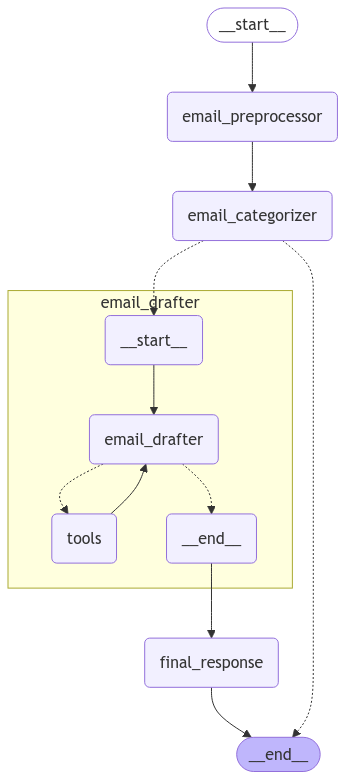

In [18]:
from IPython.display import Image, display

# Setting xray to 1 will show the internal structure of the nested graph
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [20]:
response= graph.invoke({
    
    "raw_email_body":"""
We’re currently exploring solutions to streamline our sales team's workflow. Your AI Sales Research Agent caught my eye. Could you let me know about pricing and setup requirements? Also, how does it integrate with HubSpot and let me know your availability next week for a chat????""", 
 "company_domain_name": "innovizeai.com",
"sender_email_id":"pavan.kumar@slack.com"
}
)

calling email categorizer pavan.kumar@slack.com innovizeai.com
[SystemMessage(content='You are an advanced AI system responsible for analyzing emails to determine their category and intent. The goal is to classify each email based on its type and whether it requires a response.\n\nObjective:\n\n1. Identify the category of the email (e.g., Transactional, Marketing, Sales, Customer Support, etc.).\n2. Determine the intent of the email (e.g., requires response or no response).\n\nSenders email is pavan.kumar@slack.com\nCompany Domain is innovizeai.com\n\n\nInstructions:\nGiven the following email input, perform the following steps:\n\nStep 1: Extract domain of the senders email\nGet the domain of pavan.kumar@slack.com (E.g: pavan.kumar@innovizeai.com-- > innovizeai.com\n    pavan.kumar@hubspot.com --> hubspot.com)\n\n    \nStep 2: Categorize the Email\n\n1. Always Emails are categorized as **Internal**, if the sender\'s domain matches the company domain.\n2. If the sender\'s domain does n

In [ ]:
response

In [26]:
# for chunk in graph.stream({
    
#     "raw_email_body":"""<html><body> Hi Pavan Kumar,
# Hi Team,
# what is your pricing and lets setup a call?</body></html>""",
#     "company_domain_name": "innovizeai.com",
#     "sender_email_id":"pavan.kumar@innovizeai.com"
# }, subgraphs=True):
#     print(chunk)

In [ ]:
response